In [1]:
%load_ext autoreload
%autoreload 2


In [2]:
import pandas as pd


In [3]:
data_file = "data/insurance.csv"

In [4]:
df = pd.read_csv(data_file)

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [6]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


Matplotlib is building the font cache; this may take a moment.


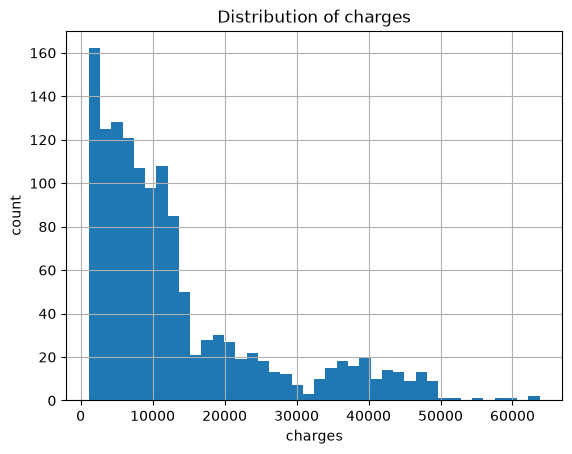

In [7]:
import matplotlib.pyplot as plt
df['charges'].hist(bins=40)
plt.xlabel('charges')
plt.ylabel('count')
plt.title('Distribution of charges')
plt.show()

In [8]:
X = df.drop('charges', axis=1)
y = df['charges']


In [9]:
# This converts sex, smoker, region into binary/one-hot columns in one call, dropping one category per column to avoid redundancy.
X = pd.get_dummies(X, columns=['sex', 'smoker', 'region'], drop_first=True)

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train[['age', 'bmi', 'children']]) # learns mu, sigma from X_train only




StandardScaler()

In [12]:
X_train_scaled = scaler.transform(X_train[['age', 'bmi', 'children']])

X_test_scaled = scaler.transform(X_test[['age', 'bmi', 'children']])  # reuses X_train's mu, sigma

In [13]:

# Convert scaled array back to a DataFrame with proper column names and original index
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=['age','bmi','children'], index=X_train.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=['age','bmi','children'], index=X_test.index)

# Combine with the one-hot encoded columns (everything in X_train except the 3 raw numeric ones)
X_train_final = pd.concat([X_train_scaled_df, X_train.drop(columns=['age','bmi','children'])], axis=1)
X_test_final = pd.concat([X_test_scaled_df, X_test.drop(columns=['age','bmi','children'])], axis=1)

In [14]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_final, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[3614.98,2036.23, 516.89,...,-370.68,-657.86,-809.8 ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](8,)","['age','bmi','children',...,'region_northwest','region_southeast', 'region_southwest']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,8955
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(8)


In [15]:

coef_df = pd.DataFrame({
    'feature': model.feature_names_in_,
    'coefficient': model.coef_
})
print(coef_df)

            feature   coefficient
0               age   3614.975415
1               bmi   2036.228123
2          children    516.890247
3          sex_male    -18.591692
4        smoker_yes  23651.128856
5  region_northwest   -370.677326
6  region_southeast   -657.864297
7  region_southwest   -809.799354


In [16]:


y_train_pred = model.predict(X_train_final)
y_test_pred = model.predict(X_test_final)



print("Train MSE:", train_mse)
print("Test MSE:", test_mse)

Train MSE: 37277681.70201866
Test MSE: 33596915.85136149


In [21]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# R-squared: How much of the 'variance' in charges does your model explain?
# (Goal: Close to 1.0. Without interaction, this is usually ~0.75)

# Root Mean Squared Error (RMSE): Punishes large outliers.
# If this is much higher than MAE, your model is failing badly on specific rows.

# 2. Mean Absolute Error (MAE): The "Human" metric.
# Tells you: "On average, my prediction is off by $X dollars."



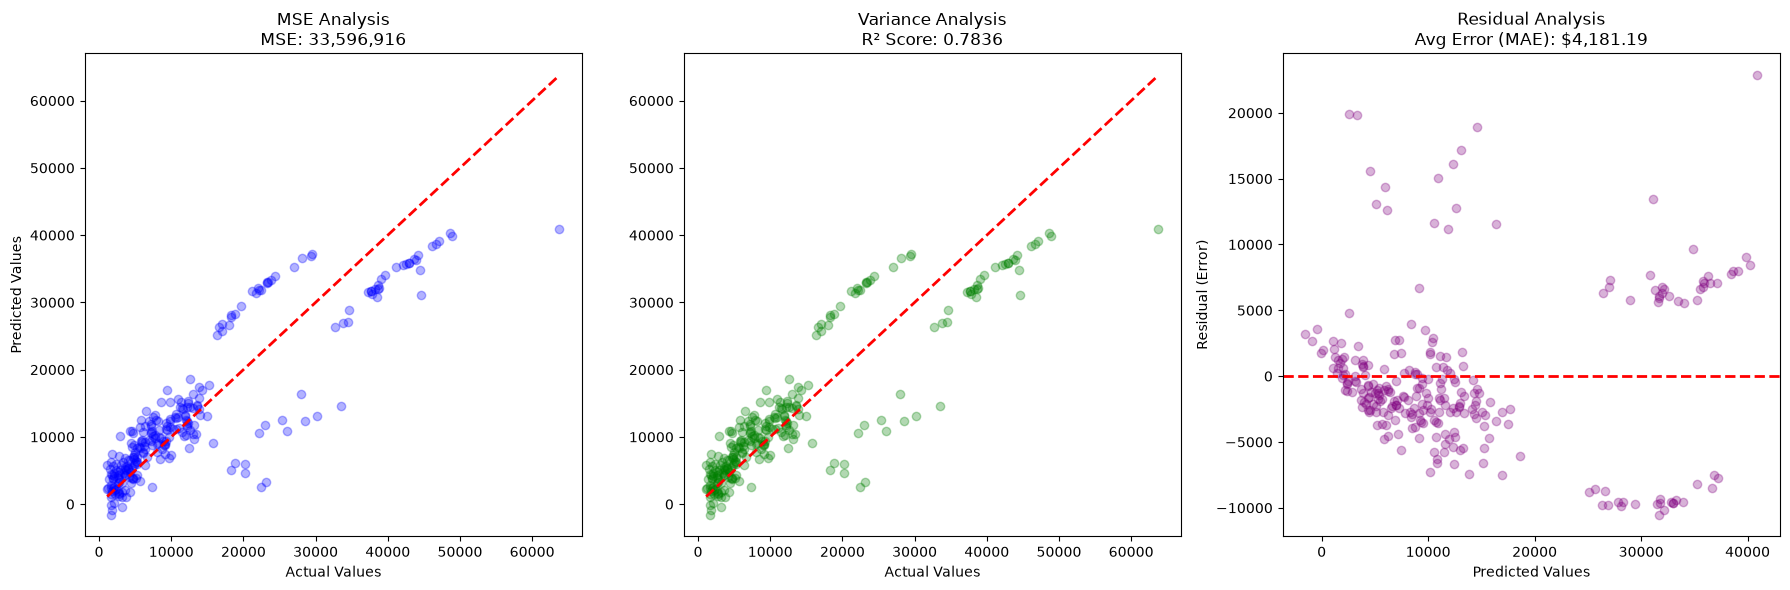

In [22]:
from machine_learning.core.graphs import plot_model_performance
plot_model_performance(y_test.values, y_test_pred)


### 1. R² — "How much of the puzzle did I solve?"

Charges vary a lot between patients — some pay $1,200, others $60,000. That variation has causes: age, smoking, bmi, etc. R² asks: of all that variation, how much can my model's features actually explain?

𝑅2 = 0.7509 → 75% explained 

Concretely: if we lined up 100 patients and asked "why does patient A pay more than patient B?" — the model's answer (based on age, bmi, smoker, etc.) gets  75% of the way to the truth. The remaining 25% is caused by things not in the dataset — exact smoking amount, family medical history, pre-existing conditions, insurance plan type, etc. This is a property of the whole model, one single number, not tied to any specific patient.

---


### 2. MAE — "On a typical day, how far off am I?"

Take every patient's error (actual − predicted), take the absolute value (so overprediction and underprediction count equally), average them.

MAE=$4,170.89

Concretely: pick a random patient. Our best single guess for *how wrong will I be* is about `$4,171`, in either direction.  If a patient's real charge is `$10,000`, the model might predict anywhere from ~ `$5,800` to ~ `$14,200` typically. This is the "typical/normal" error — treats a `$1` error and a `$4,000` error proportionally.

---


### 3. RMSE — "How bad are my worst mistakes?"

Same idea as MAE, but squares each error before averaging (then square-roots at the end to bring it back to dollars). Squaring inflates big errors disproportionately (you derived this yourself, way back at the start of session 1 — a $100 error becomes 10,000 when squared; a $10,000 error becomes 100,000,000).


RMSE=$6,041.68

The key move — comparing MAE and RMSE directly:

RMSE−MAE = 6041.68−4170.89= `$1,870.79`

If the model were equally wrong on every single patient (no outliers), MAE and RMSE would be nearly identical — squaring then square-rooting a bunch of equal numbers just gives you back that same number. The fact that RMSE is meaningfully higher tells that, a handful of patients have much larger errors dragging RMSE up, while most patients have errors closer to the $4,171 MAE figure.

---

#### Putting it all together — is this model "good"?

| Metric          | Value  | Verdict                                                                                            |
| --------------- | ------ | -------------------------------------------------------------------------------------------------- |
| R²              | 0.75   | Explains most, but not all, of the variation — solid for messy human health data.                  |
| MAE             | `$4,171` | Typical prediction is off by approximately `$4k` — usable but not precise.                           |
| RMSE vs MAE gap | `$1,871` | The model struggles specifically on high-cost patients, rather than making uniformly sized errors. |


---


Verdict: A reasonably good baseline that captures the dominant cost driver (smoking) well, but systematically underperforms on the most expensive patients — likely because "smoker: yes/no" is too coarse (it can't distinguish a light smoker from a heavy smoker with early complications). 

The baseline model's residual analysis showed prediction errors ballooning specifically for patients with actual charges above ~$20,000 — not uniformly across the whole range. This pointed to a subgroup of patients being poorly modeled, rather than a general curvature problem.

---


In [25]:
X_train_final['smoker_bmi'] = X_train_final['smoker_yes'] * X_train_final['bmi']
X_test_final['smoker_bmi'] = X_test_final['smoker_yes'] * X_test_final['bmi']

model2 = LinearRegression()
model2.fit(X_train_final, y_train)

y_test_pred2 = model2.predict(X_test_final)

rmse2 = np.sqrt(mean_squared_error(y_test, y_test_pred2))
mae2 = mean_absolute_error(y_test, y_test_pred2)

print("New RMSE:", rmse2)
print("New MAE:", mae2)

New RMSE: 4573.807686290385
New MAE: 2756.898659517968


In [27]:
r2 = r2_score(y_test, y_test_pred2)
print("New R2:", r2)

New R2: 0.8652503208873077


**Result**: RMSE dropped 24% ($6,041.68 → $4,573.81), MAE dropped 34% ($4,170.89 → $2,756.90), and R² rose from 0.751 to 0.865 — confirming that the missing signal was the smoker-BMI compounding effect, not general non-linearity in any single feature.